device: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

epoch 1 iter 300/469  loss=0.5430
[epoch 1] train_loss=0.4216  test_acc=95.23%
epoch 2 iter 300/469  loss=0.1405
[epoch 2] train_loss=0.1303  test_acc=96.98%


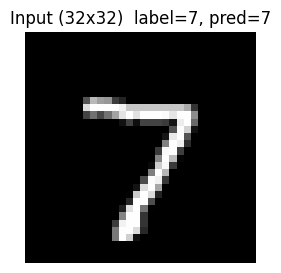

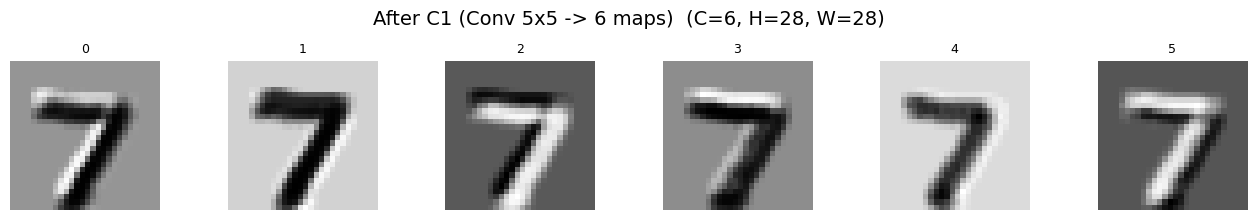

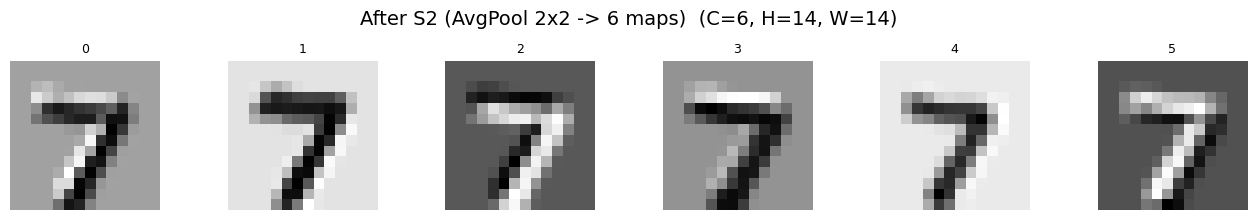

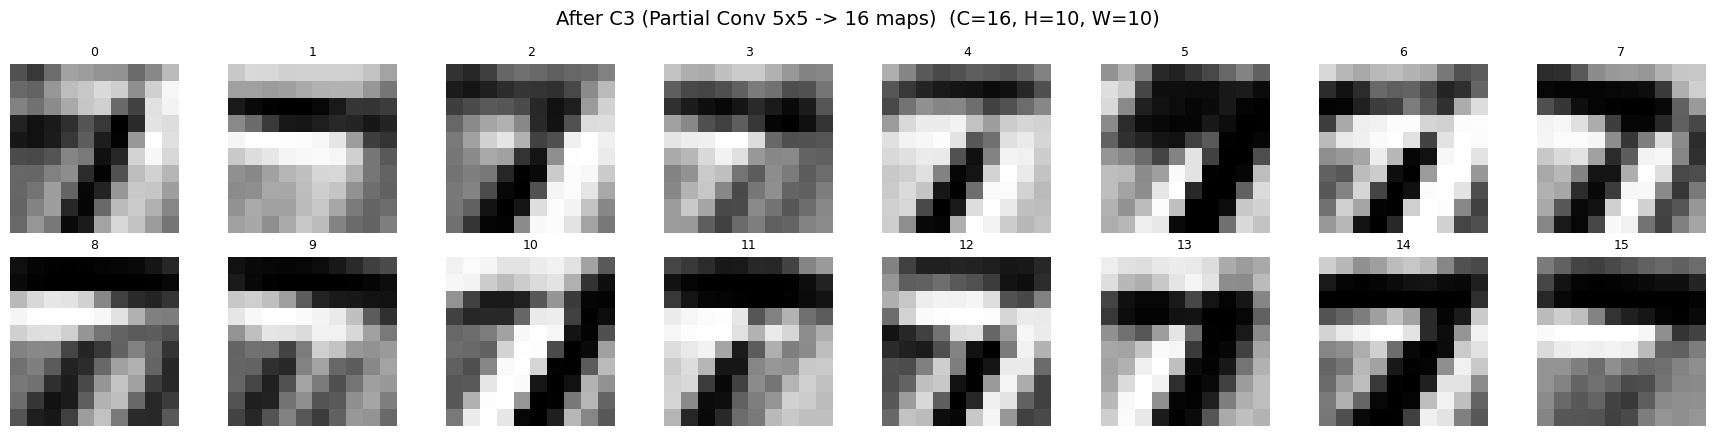

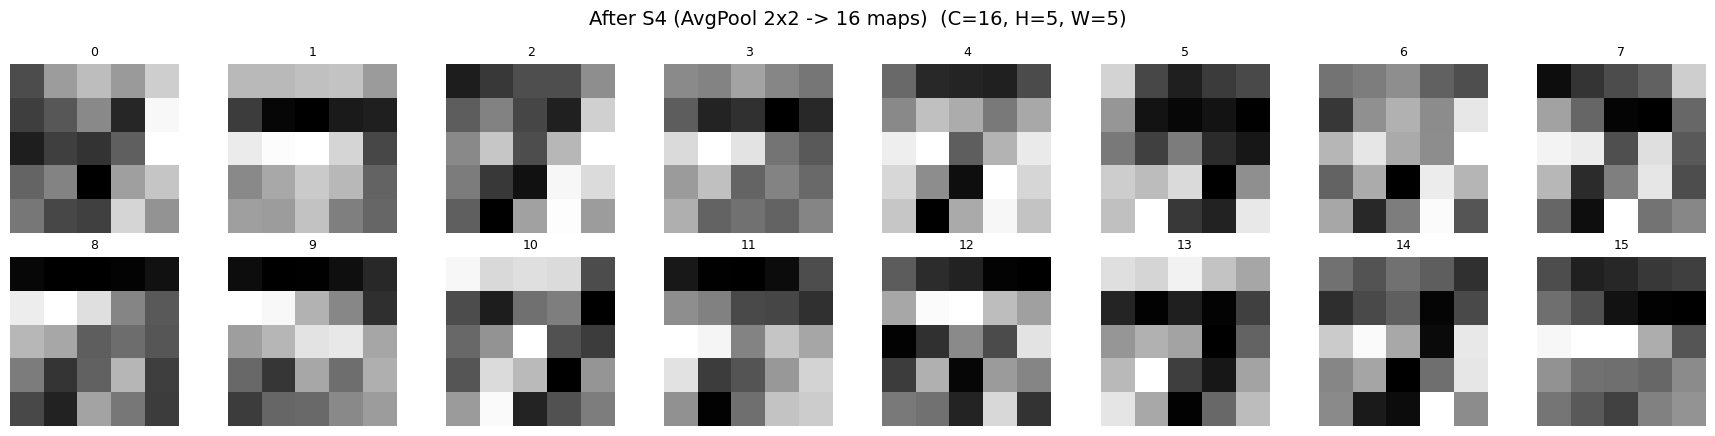

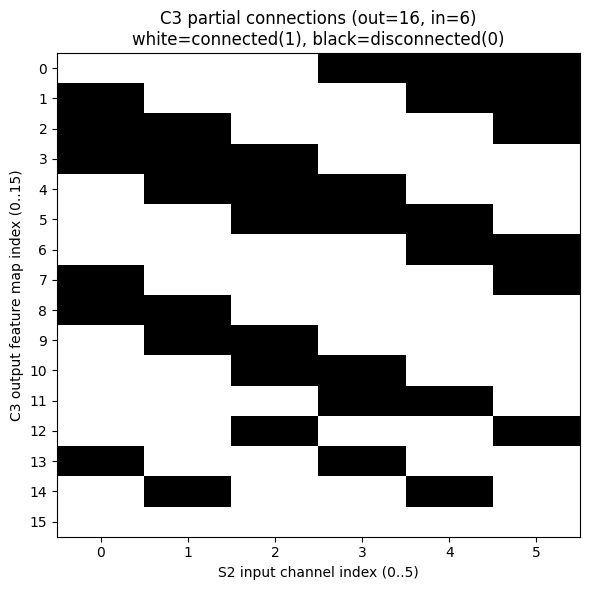

C3 connectivity list (each C3 map -> which S2 channels are used):
  C3[ 0] uses S2 channels: [0, 1, 2]
  C3[ 1] uses S2 channels: [1, 2, 3]
  C3[ 2] uses S2 channels: [2, 3, 4]
  C3[ 3] uses S2 channels: [3, 4, 5]
  C3[ 4] uses S2 channels: [0, 4, 5]
  C3[ 5] uses S2 channels: [0, 1, 5]
  C3[ 6] uses S2 channels: [0, 1, 2, 3]
  C3[ 7] uses S2 channels: [1, 2, 3, 4]
  C3[ 8] uses S2 channels: [2, 3, 4, 5]
  C3[ 9] uses S2 channels: [0, 3, 4, 5]
  C3[10] uses S2 channels: [0, 1, 4, 5]
  C3[11] uses S2 channels: [0, 1, 2, 5]
  C3[12] uses S2 channels: [0, 1, 3, 4]
  C3[13] uses S2 channels: [1, 2, 4, 5]
  C3[14] uses S2 channels: [0, 2, 3, 5]
  C3[15] uses S2 channels: [0, 1, 2, 3, 4, 5]


In [1]:
# LeNet-5 (MNIST) 실험용 PyTorch 코드
# - 32x32 입력(MNIST 28x28을 padding)
# - C3 레이어: LeNet-5 논문처럼 "부분 연결(16개 feature map이 S2의 6개 채널 중 일부만 사용)" 구현
# - 중간 점검 시각화:
#   1) 입력 이미지
#   2) C1 통과 후(6장 feature map)
#   3) S2(AvgPool) 후(6장)
#   4) C3(부분 연결) 후(16장)
#   5) S4(AvgPool) 후(16장)
#   6) C3 연결 마스크(16x6) 시각화

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# 1) 데이터: MNIST -> (1,32,32)
# -------------------------
transform = transforms.Compose([
    transforms.Pad(2),               # 28x28 -> 32x32
    transforms.ToTensor(),
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# 2) LeNet-5 C3 부분 연결 마스크 (S2 6채널 -> C3 16채널)
#    mask[out_ch, in_ch] = 1이면 연결, 0이면 미연결
#    아래 마스크는 논문 TABLE I을 그대로 0/1로 옮긴 형태입니다.
# -------------------------
C3_MASK_S2ROWS_C3COLS = [
    # rows = S2 channel index (0..5), cols = C3 map index (0..15)
    [1,0,0,0,1,1,1,0,0,1,1,1,1,0,1,1],  # S2 ch 0
    [1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,1],  # S2 ch 1
    [1,1,1,0,0,0,1,1,1,0,0,1,0,1,1,1],  # S2 ch 2
    [0,1,1,1,0,0,1,1,1,1,0,0,1,0,1,1],  # S2 ch 3
    [0,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1],  # S2 ch 4
    [0,0,0,1,1,1,0,0,1,1,1,1,0,1,1,1],  # S2 ch 5
]
# (6,16) -> (16,6)
C3_MASK = torch.tensor(C3_MASK_S2ROWS_C3COLS, dtype=torch.float32).T  # shape (16,6)

# -------------------------
# 3) 부분 연결 Conv 구현
#    - weight: (out_ch, in_ch, k, k)
#    - mask:   (out_ch, in_ch) => 연결 안 된 채널은 weight를 0으로 만들어서 conv에 포함되지 않게 함
# -------------------------
class MaskedConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, mask, stride=1, padding=0, bias=True):
        super().__init__()
        assert mask.shape == (out_channels, in_channels), f"mask must be {(out_channels, in_channels)}"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride
        self.padding = padding

        self.weight = nn.Parameter(torch.empty(out_channels, in_channels, *self.kernel_size))
        self.bias = nn.Parameter(torch.empty(out_channels)) if bias else None

        # mask는 학습하지 않는 buffer로 등록
        self.register_buffer("mask", mask.clone())

        self.reset_parameters()

    def reset_parameters(self):
        # LeNet-5 시대엔 작은 랜덤으로 시작했지만, 여기선 안정적으로 kaiming_uniform 사용
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in = self.in_channels * self.kernel_size[0] * self.kernel_size[1]
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        # 마스크 적용: 연결 안 된 (out,in) weight를 0으로
        w = self.weight * self.mask[:, :, None, None]
        return F.conv2d(x, w, self.bias, stride=self.stride, padding=self.padding)

# -------------------------
# 4) LeNet-5 모델 (C1 -> S2 -> C3(partial) -> S4 -> C5 -> F6 -> output)
#    - 활성화: 원 논문은 tanh 사용
# -------------------------
class LeNet5Partial(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.act = nn.Tanh()

        # C1: (1,32,32) -> (6,28,28)  (5x5 conv)
        self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0, bias=True)
        # S2: (6,28,28) -> (6,14,14)  (2x2 avg pool)
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: (6,14,14) -> (16,10,10) (5x5 conv, partial connect)
        self.c3 = MaskedConv2d(6, 16, kernel_size=5, stride=1, padding=0, bias=True, mask=C3_MASK)

        # S4: (16,10,10) -> (16,5,5) (2x2 avg pool)
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: (16,5,5) -> (120,1,1) (5x5 conv)
        self.c5 = nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0, bias=True)

        # F6: 120 -> 84
        self.f6 = nn.Linear(120, 84)
        # Output: 84 -> 10
        self.out = nn.Linear(84, num_classes)

        # 중간 활성값 저장용
        self._cache = {}

    def forward(self, x, cache_activations=False):
        # x: (B,1,32,32)
        x = self.c1(x)
        x = self.act(x)
        if cache_activations: self._cache["C1"] = x.detach()

        x = self.s2(x)
        if cache_activations: self._cache["S2"] = x.detach()

        x = self.c3(x)
        x = self.act(x)
        if cache_activations: self._cache["C3"] = x.detach()

        x = self.s4(x)
        if cache_activations: self._cache["S4"] = x.detach()

        x = self.c5(x)
        x = self.act(x)
        if cache_activations: self._cache["C5"] = x.detach()  # (B,120,1,1)

        x = x.view(x.size(0), -1)  # (B,120)
        x = self.f6(x)
        x = self.act(x)
        if cache_activations: self._cache["F6"] = x.detach()

        logits = self.out(x)
        if cache_activations: self._cache["LOGITS"] = logits.detach()
        return logits

# -------------------------
# 5) 시각화 유틸
# -------------------------
def show_feature_maps(tensor_chw, title, max_channels=16, cols=8):
    """
    tensor_chw: (C,H,W) torch tensor
    """
    t = tensor_chw.detach().cpu()
    C, H, W = t.shape
    C_show = min(C, max_channels)
    rows = math.ceil(C_show / cols)

    plt.figure(figsize=(cols * 2.2, rows * 2.2))
    for i in range(C_show):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(t[i], cmap="gray")
        ax.set_title(f"{i}", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"{title}  (C={C}, H={H}, W={W})", fontsize=14)
    plt.tight_layout()
    plt.show()

def show_connection_mask(mask_out_in):
    """
    mask_out_in: (out_ch, in_ch) 0/1
    """
    m = mask_out_in.detach().cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(m, cmap="gray", aspect="auto")
    plt.title("C3 partial connections (out=16, in=6)\nwhite=connected(1), black=disconnected(0)")
    plt.xlabel("S2 input channel index (0..5)")
    plt.ylabel("C3 output feature map index (0..15)")
    plt.xticks(range(m.shape[1]))
    plt.yticks(range(m.shape[0]))
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def inspect_one_sample(model, dataset_index=0):
    model.eval()
    x, y = test_ds[dataset_index]
    x = x.unsqueeze(0).to(device)  # (1,1,32,32)

    logits = model(x, cache_activations=True)
    pred = logits.argmax(dim=1).item()

    # 입력
    plt.figure(figsize=(3,3))
    plt.imshow(x[0,0].detach().cpu(), cmap="gray")
    plt.title(f"Input (32x32)  label={y}, pred={pred}")
    plt.axis("off")
    plt.show()

    # 중간 feature map들
    show_feature_maps(model._cache["C1"][0], "After C1 (Conv 5x5 -> 6 maps)", max_channels=6, cols=6)
    show_feature_maps(model._cache["S2"][0], "After S2 (AvgPool 2x2 -> 6 maps)", max_channels=6, cols=6)
    show_feature_maps(model._cache["C3"][0], "After C3 (Partial Conv 5x5 -> 16 maps)", max_channels=16, cols=8)
    show_feature_maps(model._cache["S4"][0], "After S4 (AvgPool 2x2 -> 16 maps)", max_channels=16, cols=8)

    # C3 연결 구조(16x6) 시각화
    show_connection_mask(model.c3.mask)

    # “각 C3 필터가 어떤 S2 채널을 쓰는지” 텍스트로도 확인
    m = model.c3.mask.detach().cpu().numpy().astype(int)
    print("C3 connectivity list (each C3 map -> which S2 channels are used):")
    for out_ch in range(m.shape[0]):
        used = np.where(m[out_ch] == 1)[0].tolist()
        print(f"  C3[{out_ch:2d}] uses S2 channels: {used}")

# -------------------------
# 6) 빠른 학습 루프(원하면 epoch 늘리기)
# -------------------------
def train_one_epoch(model, loader, optim, epoch=1, log_every=200):
    model.train()
    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    for it, (x, y) in enumerate(loader, start=1):
        x, y = x.to(device), y.to(device)
        optim.zero_grad()
        logits = model(x)
        loss = ce(logits, y)
        loss.backward()
        optim.step()
        total_loss += loss.item()
        if it % log_every == 0:
            print(f"epoch {epoch} iter {it}/{len(loader)}  loss={total_loss/it:.4f}")
    return total_loss / len(loader)

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# 7) 실행
# -------------------------
model = LeNet5Partial().to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

# (선택) 학습 조금만 돌려서 feature map이 “그럴듯하게” 나오게 만들기
for ep in range(1, 3):  # 필요하면 5~10으로 늘리세요
    train_loss = train_one_epoch(model, train_loader, optim, epoch=ep, log_every=300)
    acc = eval_acc(model, test_loader)
    print(f"[epoch {ep}] train_loss={train_loss:.4f}  test_acc={acc*100:.2f}%")

# 중간 결과 점검(원하는 인덱스로 바꿔가며 보기)
inspect_one_sample(model, dataset_index=0)
